In [ ]:
# CodeAlpha Internship
# Project 1: Credit Scoring Model
print("CodeAlpha - Credit Scoring Model")
print("Project 1")

CodeAlpha - Credit Scoring Model
Project 1


# Credit Scoring Model

## CodeAlpha Machine Learning Internship — Project 1

### Project Overview

This project develops a machine learning classification model to predict creditworthiness using financial and customer-related information.

The project follows a complete machine learning workflow including data acquisition, exploratory data analysis, preprocessing, model development, evaluation, model comparison, and final prediction.

### Objective

The objective is to classify individuals into credit risk categories using machine learning techniques and evaluate the models using multiple classification metrics.

### Models

The following classification algorithms will be evaluated:

- Logistic Regression
- Decision Tree
- Random Forest

### Evaluation Metrics

- Accuracy
- Precision
- Recall
- F1-Score
- ROC-AUC
- Confusion Matrix

In [ ]:
!pip -q install ucimlrepo

In [ ]:
from ucimlrepo import fetch_ucirepo
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
print("Libraries imported successfully.")

Libraries imported successfully.


In [ ]:
# Fetch UCI Statlog German Credit dataset
credit_data = fetch_ucirepo(id=144)
X = credit_data.data.features
y = credit_data.data.targets
print("Dataset loaded successfully.")
print("Features shape:", X.shape)
print("Target shape:", y.shape)

Dataset loaded successfully.
Features shape: (1000, 20)
Target shape: (1000, 1)


In [ ]:
display(X.head())

,Attribute1,Attribute2,Attribute3,Attribute4,Attribute5,Attribute6,Attribute7,Attribute8,Attribute9,Attribute10,Attribute11,Attribute12,Attribute13,Attribute14,Attribute15,Attribute16,Attribute17,Attribute18,Attribute19,Attribute20
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,4,A121,67,A143,A152,2,A173,1,A192,A201
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,2,A121,22,A143,A152,1,A173,1,A191,A201
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,3,A121,49,A143,A152,1,A172,2,A191,A201
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,4,A122,45,A143,A153,1,A173,2,A191,A201
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,4,A124,53,A143,A153,2,A173,2,A191,A201


In [ ]:
print("Feature columns:")
print(X.columns.tolist())

Feature columns:
['Attribute1', 'Attribute2', 'Attribute3', 'Attribute4', 'Attribute5', 'Attribute6', 'Attribute7', 'Attribute8', 'Attribute9', 'Attribute10', 'Attribute11', 'Attribute12', 'Attribute13', 'Attribute14', 'Attribute15', 'Attribute16', 'Attribute17', 'Attribute18', 'Attribute19', 'Attribute20']


In [ ]:
print("\nTarget:")
display(y.head())


Target:


,class
0,1
1,2
2,1
3,1
4,2


In [ ]:
print("\nDataset information:")
X.info()


Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Attribute1   1000 non-null   object
 1   Attribute2   1000 non-null   int64 
 2   Attribute3   1000 non-null   object
 3   Attribute4   1000 non-null   object
 4   Attribute5   1000 non-null   int64 
 5   Attribute6   1000 non-null   object
 6   Attribute7   1000 non-null   object
 7   Attribute8   1000 non-null   int64 
 8   Attribute9   1000 non-null   object
 9   Attribute10  1000 non-null   object
 10  Attribute11  1000 non-null   int64 
 11  Attribute12  1000 non-null   object
 12  Attribute13  1000 non-null   int64 
 13  Attribute14  1000 non-null   object
 14  Attribute15  1000 non-null   object
 15  Attribute16  1000 non-null   int64 
 16  Attribute17  1000 non-null   object
 17  Attribute18  1000 non-null   int64 
 18  Attribute19  1000 non-null   object
 19  Attrib

In [ ]:
print("\nMissing values:")
print(X.isnull().sum().sum())


Missing values:
0


## Target Variable Preparation

The original UCI dataset encodes credit risk as:

- 1 = Good credit risk
- 2 = Bad credit risk

For machine learning evaluation, the target is transformed into a binary representation:

- 0 = Good credit
- 1 = Bad credit

This allows the model's precision, recall, F1-score, and ROC-AUC to be interpreted with bad credit risk as the positive class.

In [ ]:
# Prepare the target variable
y = y["class"].map({
    1: 0,   # Good credit
    2: 1    # Bad credit
})
print("Target encoding:")
print("0 = Good Credit")
print("1 = Bad Credit")
print("\nTarget distribution:")
print(y.value_counts())
print("\nTarget distribution (%):")
print((y.value_counts(normalize=True) * 100).round(2))

Target encoding:
0 = Good Credit
1 = Bad Credit

Target distribution:
class
0    700
1    300
Name: count, dtype: int64

Target distribution (%):
class
0    70.0
1    30.0
Name: proportion, dtype: float64


## Feature Engineering and Feature Naming

The original dataset uses generic attribute names. Based on the official UCI variable documentation, the features are renamed to meaningful names to improve readability and interpretability throughout the analysis.

In [ ]:
# Rename features using the official UCI variable descriptions

feature_names = {
    "Attribute1": "checking_account_status",
    "Attribute2": "duration_months",
    "Attribute3": "credit_history",
    "Attribute4": "purpose",
    "Attribute5": "credit_amount",
    "Attribute6": "savings_account",
    "Attribute7": "employment_duration",
    "Attribute8": "installment_rate",
    "Attribute9": "personal_status_sex",
    "Attribute10": "other_debtors",
    "Attribute11": "residence_duration",
    "Attribute12": "property",
    "Attribute13": "age",
    "Attribute14": "other_installment_plans",
    "Attribute15": "housing",
    "Attribute16": "existing_credits",
    "Attribute17": "job",
    "Attribute18": "dependents",
    "Attribute19": "telephone",
    "Attribute20": "foreign_worker"
}

X = X.rename(columns=feature_names)

display(X.head())

,checking_account_status,duration_months,credit_history,purpose,credit_amount,savings_account,employment_duration,installment_rate,personal_status_sex,other_debtors,residence_duration,property,age,other_installment_plans,housing,existing_credits,job,dependents,telephone,foreign_worker
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,4,A121,67,A143,A152,2,A173,1,A192,A201
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,2,A121,22,A143,A152,1,A173,1,A191,A201
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,3,A121,49,A143,A152,1,A172,2,A191,A201
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,4,A122,45,A143,A153,1,A173,2,A191,A201
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,4,A124,53,A143,A153,2,A173,2,A191,A201


## Dataset Overview

The dataset contains financial, employment, demographic, credit-history, housing, and other customer-related attributes.

The dataset contains both categorical and numerical variables, making appropriate preprocessing necessary before machine learning.

In [ ]:
print("Dataset shape:", X.shape)
print("\nNumerical features:")
print(X.select_dtypes(include=["int64", "float64"]).columns.tolist())
print("\nCategorical features:")
print(X.select_dtypes(include=["object"]).columns.tolist())

Dataset shape: (1000, 20)

Numerical features:
['duration_months', 'credit_amount', 'installment_rate', 'residence_duration', 'age', 'existing_credits', 'dependents']

Categorical features:
['checking_account_status', 'credit_history', 'purpose', 'savings_account', 'employment_duration', 'personal_status_sex', 'other_debtors', 'property', 'other_installment_plans', 'housing', 'job', 'telephone', 'foreign_worker']


## Check duplicates and missing values

In [ ]:
print("Missing values:", X.isnull().sum().sum())
print("Duplicate rows:", X.duplicated().sum())

Missing values: 0
Duplicate rows: 0


## Exploratory Data Analysis

### Credit Risk Distribution

The target distribution is examined to understand the proportion of good and bad credit-risk observations before model training.

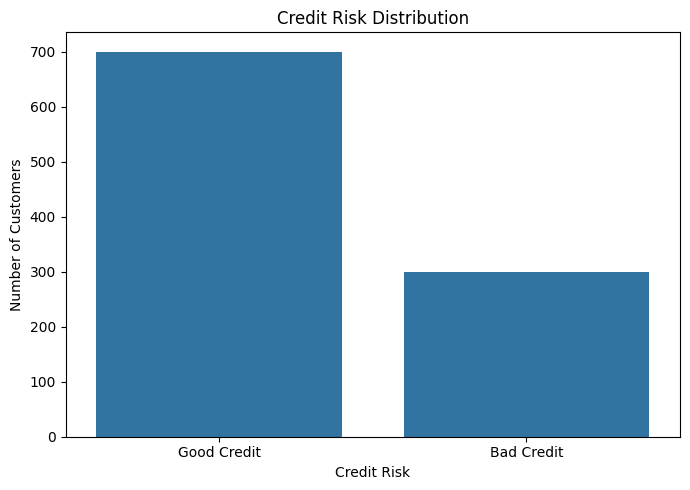

In [ ]:
plt.figure(figsize=(7, 5))
sns.countplot(
    x=y.map({
        0: "Good Credit",
        1: "Bad Credit"
    })
)

plt.title("Credit Risk Distribution")
plt.xlabel("Credit Risk")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()

## Numerical feature distributions

In [ ]:
numeric_features = X.select_dtypes(
    include=["int64", "float64"]
).columns
X[numeric_features].describe().T

,count,mean,std,min,25%,50%,75%,max
duration_months,1000.0,20.903,12.058814,4.0,12.0,18.0,24.00,72.0
credit_amount,1000.0,3271.258,2822.736876,250.0,1365.5,2319.5,3972.25,18424.0
installment_rate,1000.0,2.973,1.118715,1.0,2.0,3.0,4.00,4.0
residence_duration,1000.0,2.845,1.103718,1.0,2.0,3.0,4.00,4.0
age,1000.0,35.546,11.375469,19.0,27.0,33.0,42.00,75.0
existing_credits,1000.0,1.407,0.577654,1.0,1.0,1.0,2.00,4.0
dependents,1000.0,1.155,0.362086,1.0,1.0,1.0,1.00,2.0


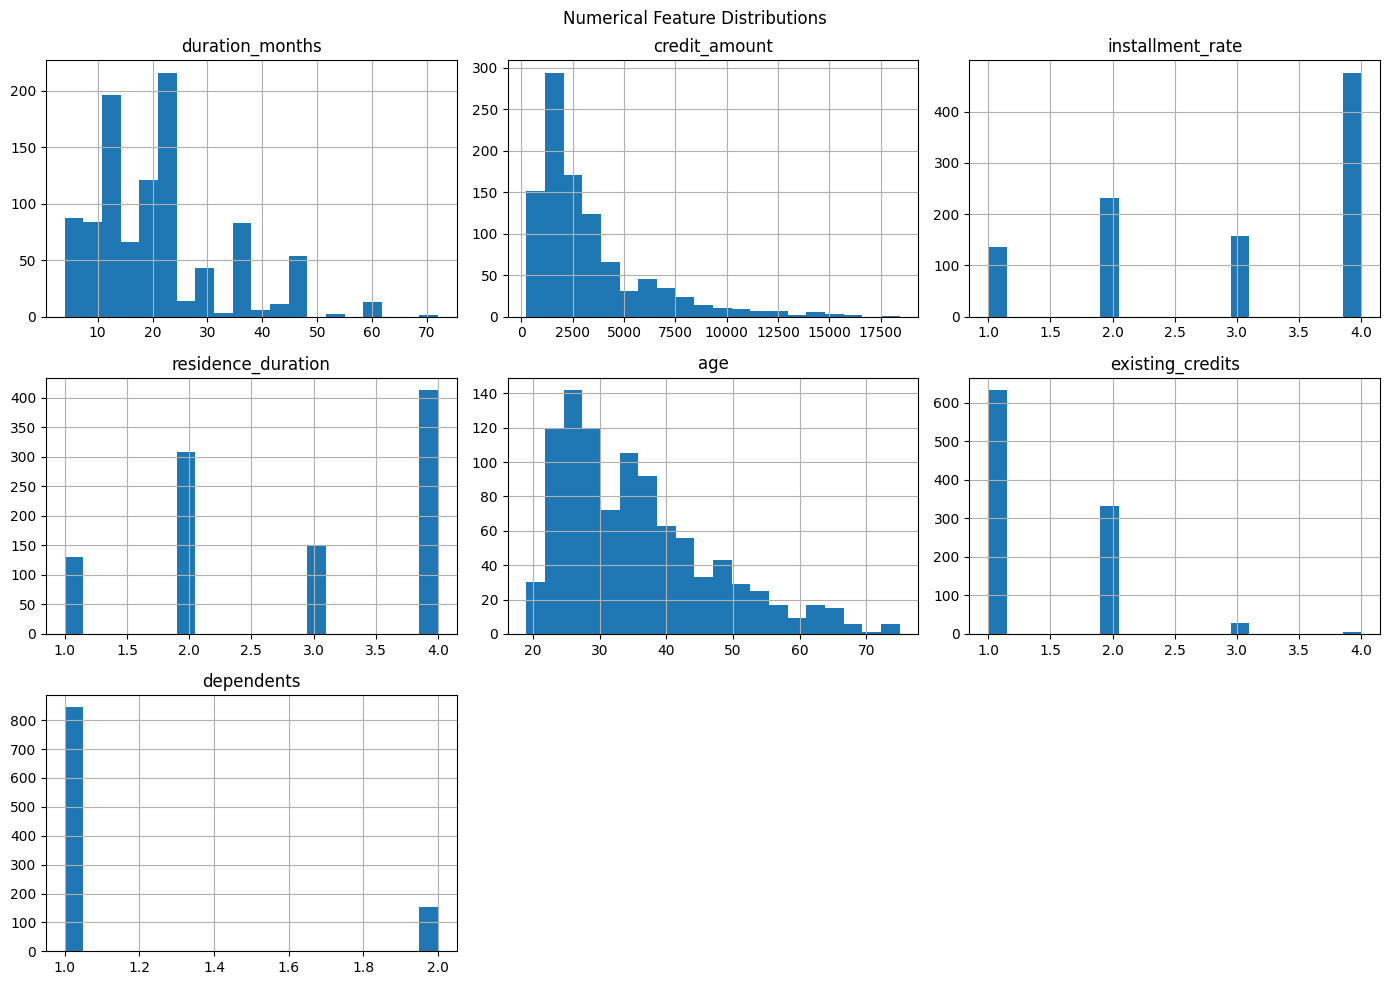

In [ ]:
X[numeric_features].hist(
    figsize=(14, 10),
    bins=20
)
plt.suptitle("Numerical Feature Distributions")
plt.tight_layout()
plt.show()

## Correlation analysis

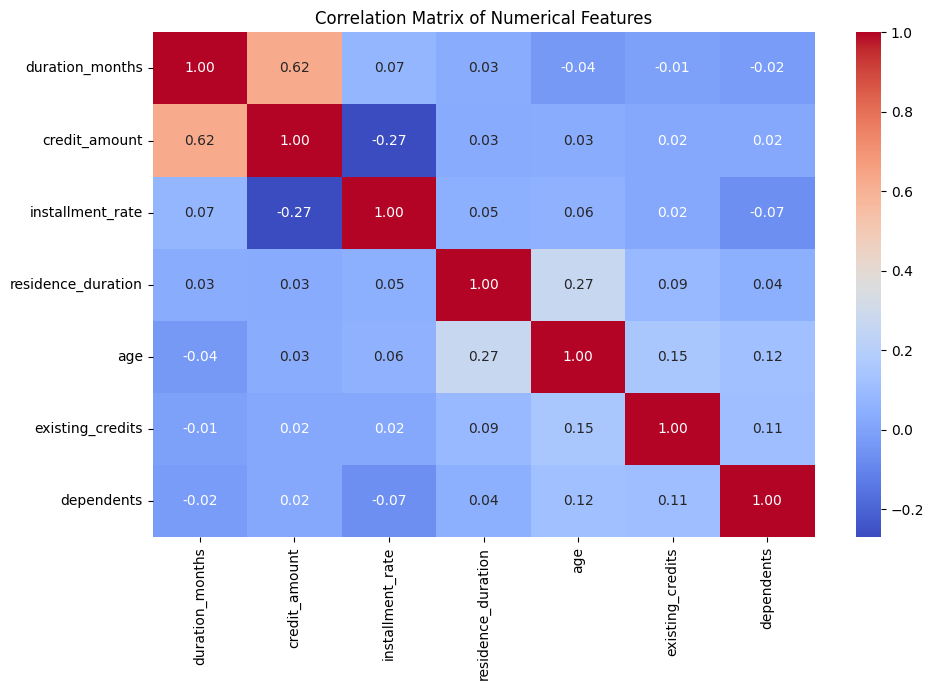

In [ ]:
plt.figure(figsize=(10, 7))
correlation_matrix = X[numeric_features].corr()
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)
plt.title("Correlation Matrix of Numerical Features")
plt.tight_layout()
plt.show()

In [ ]:
print("X shape:", X.shape)
print("y shape:", y.shape)
print("\nFirst 5 target values:")
print(y.head())

X shape: (1000, 20)
y shape: (1000,)

First 5 target values:
0    0
1    1
2    0
3    0
4    1
Name: class, dtype: int64


## Train-Test Split

The dataset is divided into training and testing subsets.

A stratified split is used so that the proportion of good and bad credit-risk cases is maintained in both subsets.

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)
print("Training set:", X_train.shape)
print("Testing set :", X_test.shape)
print("\nTraining target distribution:")
print(y_train.value_counts())
print("\nTesting target distribution:")
print(y_test.value_counts())

Training set: (800, 20)
Testing set : (200, 20)

Training target distribution:
class
0    560
1    240
Name: count, dtype: int64

Testing target distribution:
class
0    140
1     60
Name: count, dtype: int64


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
numeric_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()
categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numeric_features
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_features
        )
    ]
)
print("Numerical features:", len(numeric_features))
print("Categorical features:", len(categorical_features))

Numerical features: 7
Categorical features: 13


## create the three ML pipelines

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
logistic_pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("model", LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=42
    ))
])
decision_tree_pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("model", DecisionTreeClassifier(
        max_depth=6,
        class_weight="balanced",
        random_state=42
    ))
])
random_forest_pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=300,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])
print("All three ML pipelines created successfully.")

All three ML pipelines created successfully.


## Train all three models

In [ ]:
print("Training Logistic Regression...")
logistic_pipeline.fit(X_train, y_train)
print("Training Decision Tree...")
decision_tree_pipeline.fit(X_train, y_train)
print("Training Random Forest...")
random_forest_pipeline.fit(X_train, y_train)
print("\nAll models trained successfully.")

Training Logistic Regression...
Training Decision Tree...
Training Random Forest...

All models trained successfully.


## Evaluate all 3 models

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)
import pandas as pd
models = {
    "Logistic Regression": logistic_pipeline,
    "Decision Tree": decision_tree_pipeline,
    "Random Forest": random_forest_pipeline
}
results = []
for name, model in models.items():
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    })
results_df = pd.DataFrame(results)
for column in ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"]:
    results_df[column] = results_df[column].round(4)
display(results_df)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.750,0.5581,0.8000,0.6575,0.8058
1,Decision Tree,0.580,0.3636,0.5333,0.4324,0.5978
2,Random Forest,0.755,0.6667,0.3667,0.4731,0.7961


## Display the results as percentages

In [ ]:
results_percentage = results_df.copy()
metric_columns = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-Score",
    "ROC-AUC"
]
for column in metric_columns:
    results_percentage[column] = (
        results_percentage[column] * 100
    ).round(2).astype(str) + "%"
display(results_percentage)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,75.0%,55.81%,80.0%,65.75%,80.58%
1,Decision Tree,58.0%,36.36%,53.33%,43.24%,59.78%
2,Random Forest,75.5%,66.67%,36.67%,47.31%,79.61%


## Confusion matrices


Logistic Regression
[[102  38]
 [ 12  48]]


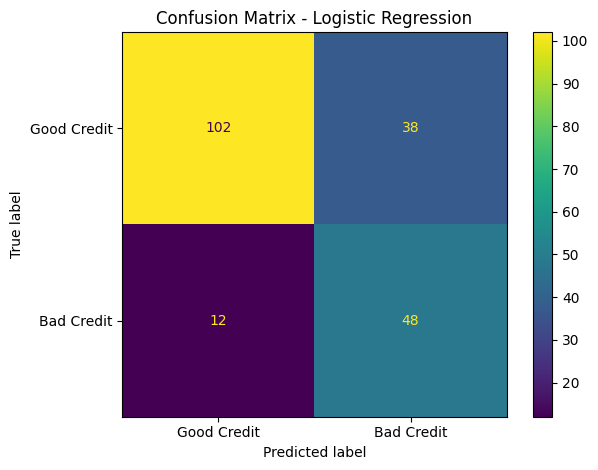


Decision Tree
[[84 56]
 [28 32]]


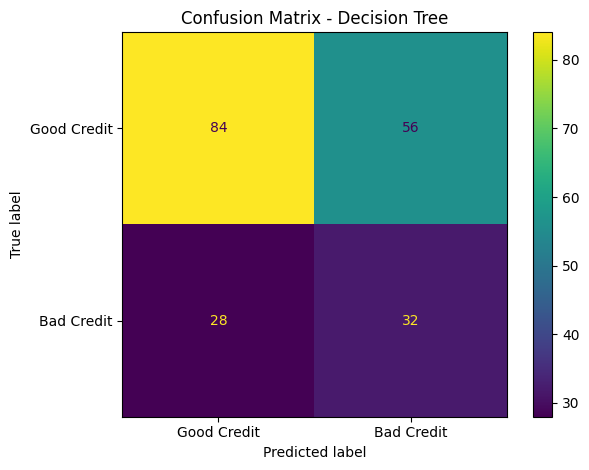


Random Forest
[[129  11]
 [ 38  22]]


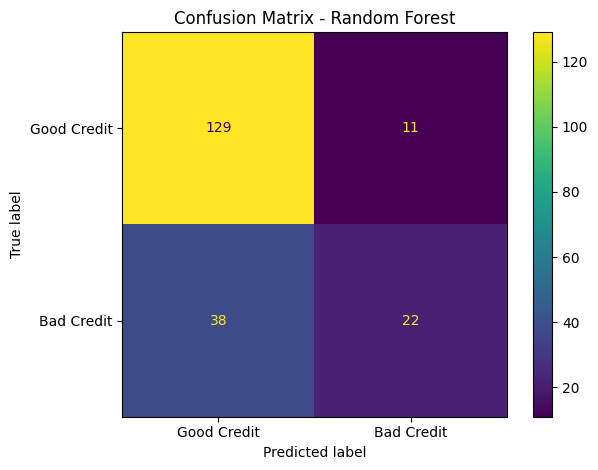

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
for name, model in models.items():
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    print(f"\n{name}")
    print(cm)
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Good Credit", "Bad Credit"]
    )
    disp.plot()
    plt.title(f"Confusion Matrix - {name}")
    plt.tight_layout()
    plt.show()

## ROC curves

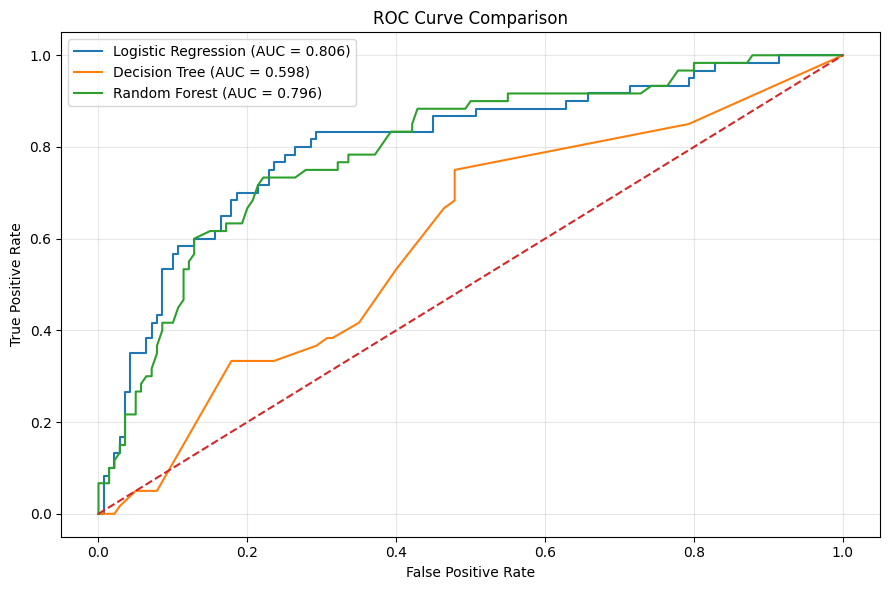

In [ ]:
from sklearn.metrics import roc_curve, auc
plt.figure(figsize=(9, 6))
for name, model in models.items():
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    plt.plot(
        fpr,
        tpr,
        label=f"{name} (AUC = {roc_auc:.3f})"
    )
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Logistic Regression was selected as the final credit-scoring model because it achieved the highest recall (80.00%), F1-score (65.75%), and ROC-AUC (80.58%) among the evaluated models, making it more suitable for identifying potentially risky credit applicants.

## Confusion Matrix for the Final Model

Confusion Matrix:
[[102  38]
 [ 12  48]]

Classification Report:
              precision    recall  f1-score   support

 Good Credit       0.89      0.73      0.80       140
  Bad Credit       0.56      0.80      0.66        60

    accuracy                           0.75       200
   macro avg       0.73      0.76      0.73       200
weighted avg       0.79      0.75      0.76       200



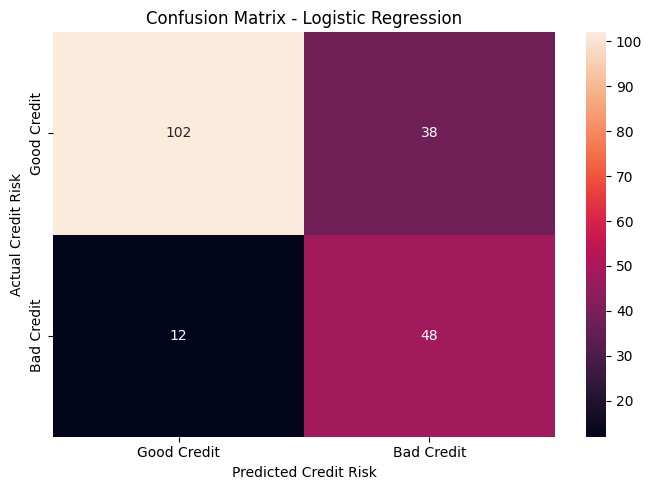

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
# Predictions from the selected final model
y_pred_final = logistic_pipeline.predict(X_test)
# Confusion matrix
cm = confusion_matrix(y_test, y_pred_final)
print("Confusion Matrix:")
print(cm)
print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_final,
        target_names=["Good Credit", "Bad Credit"]
    )
)
# Plot
plt.figure(figsize=(7, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Good Credit", "Bad Credit"],
    yticklabels=["Good Credit", "Bad Credit"]
)
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted Credit Risk")
plt.ylabel("Actual Credit Risk")
plt.tight_layout()
plt.show()

## Cross-validation

To make the project more professional, let's check whether the Logistic Regression performance is reasonably stable across different training splits.

In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_validate
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)
cv_scores = cross_validate(
    logistic_pipeline,
    X,
    y,
    cv=cv,
    scoring={
        "accuracy": "accuracy",
        "precision": "precision",
        "recall": "recall",
        "f1": "f1",
        "roc_auc": "roc_auc"
    },
    n_jobs=-1
)
cv_results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC"
    ],
    "Mean": [
        cv_scores["test_accuracy"].mean(),
        cv_scores["test_precision"].mean(),
        cv_scores["test_recall"].mean(),
        cv_scores["test_f1"].mean(),
        cv_scores["test_roc_auc"].mean()
    ],
    "Std": [
        cv_scores["test_accuracy"].std(),
        cv_scores["test_precision"].std(),
        cv_scores["test_recall"].std(),
        cv_scores["test_f1"].std(),
        cv_scores["test_roc_auc"].std()
    ]
})
cv_results["Mean"] = cv_results["Mean"].round(4)
cv_results["Std"] = cv_results["Std"].round(4)
display(cv_results)

,Metric,Mean,Std
0,Accuracy,0.7190,0.0275
1,Precision,0.5239,0.0341
2,Recall,0.7200,0.0414
3,F1-Score,0.6061,0.0342
4,ROC-AUC,0.7855,0.0192


## Analyze Feature Importance

In [ ]:
# Feature Importance - Logistic Regression
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# Get fitted preprocessing and model
fitted_preprocessor = logistic_pipeline.named_steps["preprocessing"]
logistic_model = logistic_pipeline.named_steps["model"]
# Get transformed feature names
transformed_features = fitted_preprocessor.get_feature_names_out()
# Get logistic regression coefficients
coefficients = logistic_model.coef_[0]
# Create dataframe
coef_df = pd.DataFrame({
    "Transformed_Feature": transformed_features,
    "Coefficient": coefficients,
    "Absolute_Coefficient": np.abs(coefficients)
})
# Function to map transformed features back to original features
original_features = []
for feature in transformed_features:
    if feature.startswith("num__"):
        original_features.append(
            feature.replace("num__", "")
        )
    elif feature.startswith("cat__"):
        remaining = feature.replace("cat__", "")
        matched_feature = None
        for categorical_feature in categorical_features:
            prefix = categorical_feature + "_"
            if remaining.startswith(prefix):
                matched_feature = categorical_feature
                break
        original_features.append(
            matched_feature if matched_feature else remaining
        )
    else:
        original_features.append(feature)
coef_df["Original_Feature"] = original_features
# Aggregate absolute coefficient strength by original feature
feature_importance = (
    coef_df
    .groupby("Original_Feature")["Absolute_Coefficient"]
    .sum()
    .sort_values(ascending=False)
)
print("Feature importance ranking:")
display(feature_importance.to_frame("Importance"))

Feature importance ranking:


,Importance
Original_Feature,
purpose,4.295787
savings_account,1.969601
checking_account_status,1.891703
credit_history,1.818093
employment_duration,1.389686
property,1.353819
foreign_worker,1.219724
personal_status_sex,1.006499
housing,1.003914


## Plot Top 10 Features

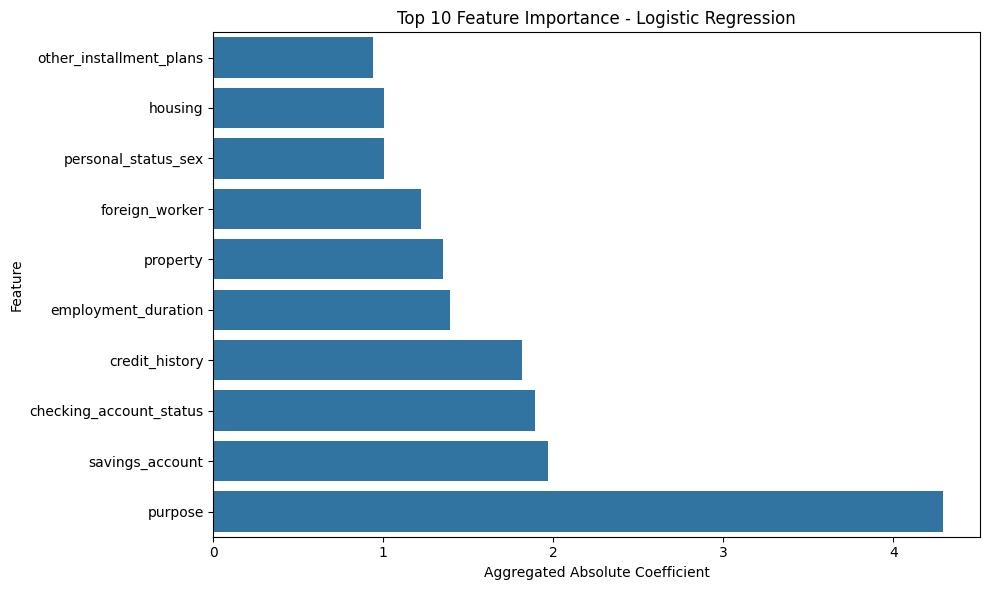

In [ ]:
top_features = feature_importance.head(10).sort_values()
plt.figure(figsize=(10, 6))
sns.barplot(
    x=top_features.values,
    y=top_features.index
)
plt.title("Top 10 Feature Importance - Logistic Regression")
plt.xlabel("Aggregated Absolute Coefficient")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

## Final Model Prediction

In [ ]:
# Final Credit Risk Prediction Demonstration
# Select a few real customers from the test set
sample_customers = X_test.iloc[:5].copy()
# Generate predictions
sample_predictions = logistic_pipeline.predict(sample_customers)
# Generate probability of Bad Credit
sample_probabilities = logistic_pipeline.predict_proba(sample_customers)[:, 1]
# Create result table
prediction_results = sample_customers.copy()
prediction_results["Actual_Risk"] = y_test.loc[sample_customers.index].map({
    0: "Good Credit",
    1: "Bad Credit"
})
prediction_results["Predicted_Risk"] = np.where(
    sample_predictions == 1,
    "Bad Credit",
    "Good Credit"
)
prediction_results["Bad_Credit_Probability"] = (
    sample_probabilities * 100
).round(2)
display(
    prediction_results[
        [
            "Actual_Risk",
            "Predicted_Risk",
            "Bad_Credit_Probability"
        ]
    ]
)

,Actual_Risk,Predicted_Risk,Bad_Credit_Probability
30,Good Credit,Good Credit,40.66
128,Good Credit,Good Credit,18.67
289,Bad Credit,Bad Credit,78.13
216,Good Credit,Bad Credit,71.57
966,Bad Credit,Good Credit,31.02


## Model Comparison Chart

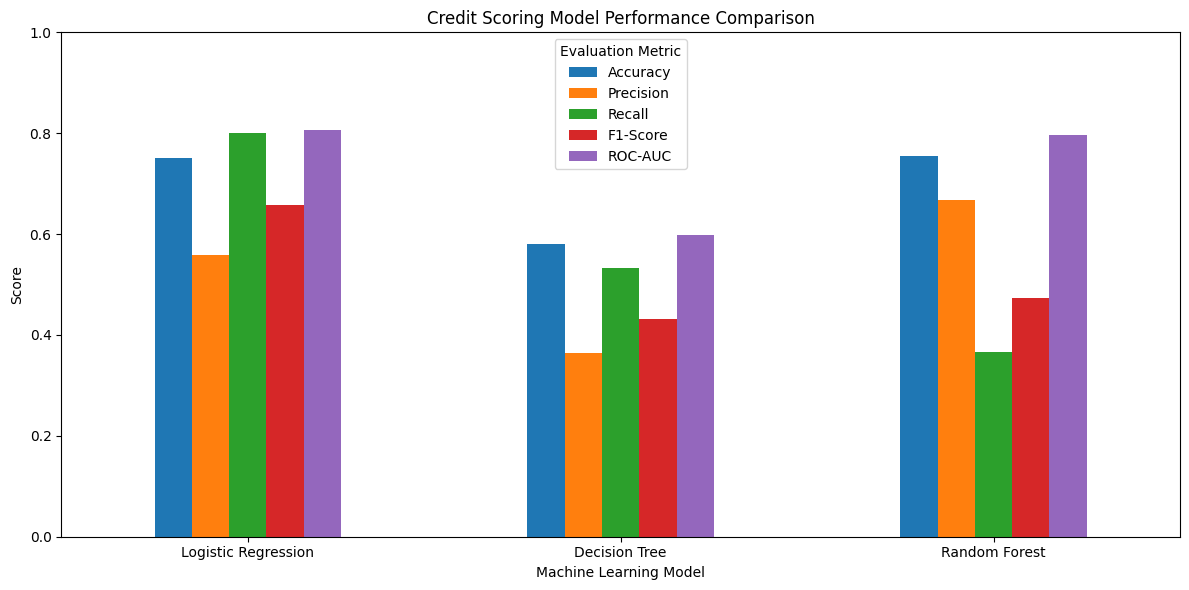

In [ ]:
# Model Performance Comparison
comparison_plot = results_df.set_index("Model")[
    ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"]
]
ax = comparison_plot.plot(
    kind="bar",
    figsize=(12, 6)
)
plt.title("Credit Scoring Model Performance Comparison")
plt.xlabel("Machine Learning Model")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(title="Evaluation Metric")
plt.tight_layout()
plt.show()

## Create the ROC Curve Again

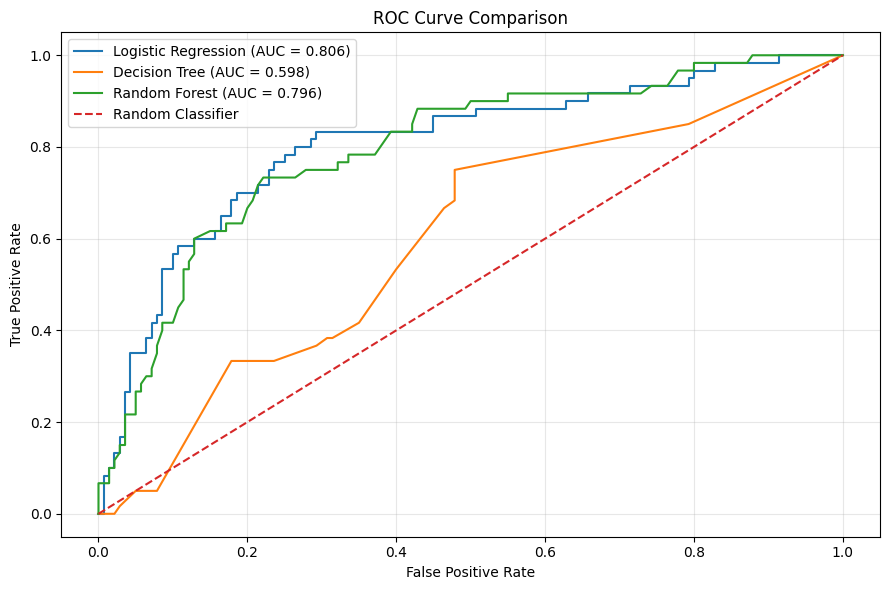

In [ ]:
# ROC Curve Comparison
plt.figure(figsize=(9, 6))
for name, model in models.items():
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = roc_auc_score(y_test, y_prob)
    plt.plot(
        fpr,
        tpr,
        label=f"{name} (AUC = {roc_auc:.3f})"
    )
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Save Resukts in Colab

In [ ]:
import os

os.makedirs("results", exist_ok=True)

# Save Credit Risk Distribution
plt.figure(figsize=(7,5))
sns.countplot(x=y.map({0:"Good Credit",1:"Bad Credit"}))
plt.title("Credit Risk Distribution")
plt.xlabel("Credit Risk")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.savefig("results/credit_risk_distribution.png", dpi=300)
plt.close()

# Save Correlation Matrix
plt.figure(figsize=(10,7))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Matrix")
plt.tight_layout()
plt.savefig("results/correlation_matrix.png", dpi=300)
plt.close()

# Save Confusion Matrix
plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=["Good Credit","Bad Credit"],
            yticklabels=["Good Credit","Bad Credit"])
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.savefig("results/confusion_matrix.png", dpi=300)
plt.close()

# Save Feature Importance
plt.figure(figsize=(10,6))
sns.barplot(x=top_features.values,y=top_features.index)
plt.title("Top 10 Feature Importance")
plt.tight_layout()
plt.savefig("results/feature_importance.png", dpi=300)
plt.close()

# Save Model Comparison
results_df.to_csv("results/model_comparison.csv", index=False)

print("All project files saved successfully.")

All project files saved successfully.


In [ ]:
# ==========================================
# SAVE ALL PROJECT RESULTS
# ==========================================

import os
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Create results folder
os.makedirs("results", exist_ok=True)

# ------------------------------------------
# 1. Credit Risk Distribution
# ------------------------------------------

plt.figure(figsize=(7, 5))

sns.countplot(
    x=y.map({
        0: "Good Credit",
        1: "Bad Credit"
    })
)

plt.title("Credit Risk Distribution")
plt.xlabel("Credit Risk")
plt.ylabel("Number of Customers")
plt.tight_layout()

plt.savefig(
    "results/credit_risk_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.close()


# ------------------------------------------
# 2. Correlation Matrix
# ------------------------------------------

plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Matrix of Numerical Features")
plt.tight_layout()

plt.savefig(
    "results/correlation_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.close()


# ------------------------------------------
# 3. Confusion Matrix
# ------------------------------------------

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Good Credit", "Bad Credit"],
    yticklabels=["Good Credit", "Bad Credit"]
)

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted Credit Risk")
plt.ylabel("Actual Credit Risk")
plt.tight_layout()

plt.savefig(
    "results/confusion_matrix_logistic_regression.png",
    dpi=300,
    bbox_inches="tight"
)

plt.close()


# ------------------------------------------
# 4. ROC Curve Comparison
# ------------------------------------------

plt.figure(figsize=(9, 6))

for name, model in models.items():

    y_prob = model.predict_proba(X_test)[:, 1]

    fpr, tpr, _ = roc_curve(y_test, y_prob)

    roc_auc = roc_auc_score(y_test, y_prob)

    plt.plot(
        fpr,
        tpr,
        label=f"{name} (AUC = {roc_auc:.3f})"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    "results/roc_curve_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.close()


# ------------------------------------------
# 5. Feature Importance
# ------------------------------------------

plt.figure(figsize=(10, 6))

sns.barplot(
    x=top_features.values,
    y=top_features.index
)

plt.title("Top 10 Feature Importance - Logistic Regression")
plt.xlabel("Aggregated Absolute Coefficient")
plt.ylabel("Feature")
plt.tight_layout()

plt.savefig(
    "results/feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.close()


# ------------------------------------------
# 6. Model Comparison CSV
# ------------------------------------------

results_df.to_csv(
    "results/model_comparison.csv",
    index=False
)


# ------------------------------------------
# 7. Cross-Validation Results CSV
# ------------------------------------------

cv_results.to_csv(
    "results/cross_validation_results.csv",
    index=False
)


# ------------------------------------------
# 8. Sample Prediction Results CSV
# ------------------------------------------

prediction_results.to_csv(
    "results/sample_predictions.csv",
    index=False
)


print("==========================================")
print("ALL RESULTS SAVED SUCCESSFULLY")
print("==========================================")

print("\nFiles created:")

for file in sorted(os.listdir("results")):
    print("✓", file)

ALL RESULTS SAVED SUCCESSFULLY

Files created:
✓ confusion_matrix.png
✓ confusion_matrix_logistic_regression.png
✓ correlation_matrix.png
✓ credit_risk_distribution.png
✓ cross_validation_results.csv
✓ feature_importance.png
✓ model_comparison.csv
✓ roc_curve_comparison.png
✓ sample_predictions.csv


In [ ]:
import os
print("RESULTS FOLDER")
for file in sorted(os.listdir("results")):
    file_path = os.path.join("results", file)
    size_kb = os.path.getsize(file_path) / 1024
    print(f"✓ {file:<45} {size_kb:.2f} KB")

RESULTS FOLDER
✓ confusion_matrix.png                          96.10 KB
✓ confusion_matrix_logistic_regression.png      103.88 KB
✓ correlation_matrix.png                        268.91 KB
✓ credit_risk_distribution.png                  76.47 KB
✓ cross_validation_results.csv                  0.12 KB
✓ feature_importance.png                        140.95 KB
✓ model_comparison.csv                          0.19 KB
✓ roc_curve_comparison.png                      216.08 KB
✓ sample_predictions.csv                        0.85 KB
